In [6]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, auc,
from sklearn.svm import SVC

In [26]:
#Az adathalmaz megismerése Az adathalmaz StarCraft 2 játékosok teljesítménymutatóit és képernyőmozgásait tartalmazza. 
#Az idő rögzítése a visszajátszási fájl időbélyegeiben (timestamps) történik. 
#Jellemző attribútumok például az egyedi azonosító (GameID), a liga besorolás (LeagueIndex 1-től 8-ig kódolva), 
#az életkor (Age), valamint folyamatos változók, mint az APM (Action per minute) és a PAC (Perception Action Cycles) metrikák.

In [2]:
df = pd.read_csv('data_1.csv')

In [3]:
df.head()

,GameID,LeagueIndex,Age,HoursPerWeek,TotalHours,APM,SelectByHotkeys,AssignToHotkeys,UniqueHotkeys,MinimapAttacks,MinimapRightClicks,NumberOfPACs,GapBetweenPACs,ActionLatency,ActionsInPAC,TotalMapExplored,WorkersMade,UniqueUnitsMade,ComplexUnitsMade,ComplexAbilitiesUsed
0,52,5,27,10,3000,143.7180,0.003515,0.000220,7,0.000110,0.000392,0.004849,32.6677,40.8673,4.7508,28,0.001397,6,0.0,0.000000
1,55,5,23,10,5000,129.2322,0.003304,0.000259,4,0.000294,0.000432,0.004307,32.9194,42.3454,4.8434,22,0.001193,5,0.0,0.000208
2,56,4,30,10,200,69.9612,0.001101,0.000336,4,0.000294,0.000461,0.002926,44.6475,75.3548,4.0430,22,0.000745,6,0.0,0.000189
3,57,3,19,20,400,107.6016,0.001034,0.000213,1,0.000053,0.000543,0.003783,29.2203,53.7352,4.9155,19,0.000426,7,0.0,0.000384
4,58,3,32,10,500,122.8908,0.001136,0.000327,2,0.000000,0.001329,0.002368,22.6885,62.0813,9.3740,15,0.001174,4,0.0,0.000019


In [27]:
#Előfeldolgozás, adattisztítás A hiányzó adatokat és extrém értékeket feltérképezzük. 
#A GameID attribútum csupán egy egyedi azonosító, ami a gépi tanulási modellek számára nem hordoz információt, így ezt eltávolítjuk.

In [4]:
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')

df = df.dropna()
if 'GameID' in df.columns:
    df = df.drop('GameID', axis=1)
df.head()
print(df.dtypes)

LeagueIndex               int64
Age                     float64
HoursPerWeek            float64
TotalHours              float64
APM                     float64
SelectByHotkeys         float64
AssignToHotkeys         float64
UniqueHotkeys             int64
MinimapAttacks          float64
MinimapRightClicks      float64
NumberOfPACs            float64
GapBetweenPACs          float64
ActionLatency           float64
ActionsInPAC            float64
TotalMapExplored          int64
WorkersMade             float64
UniqueUnitsMade           int64
ComplexUnitsMade        float64
ComplexAbilitiesUsed    float64
dtype: object


In [ ]:
#Vizualizációs eszközök használata Az attribútumok között fennálló kapcsolatok feltárására legalább öt különböző vizualizációs eszközt alkalmazunk.
#Ezen eredmények a későbbi (pl. attribútum kiválasztási) feladatok során is hasznosak lehetnek. 
#Két/több attribútum együttes vizsgálatához megfelelő plotokat (pl. scatterplot, pairplot) használunk.

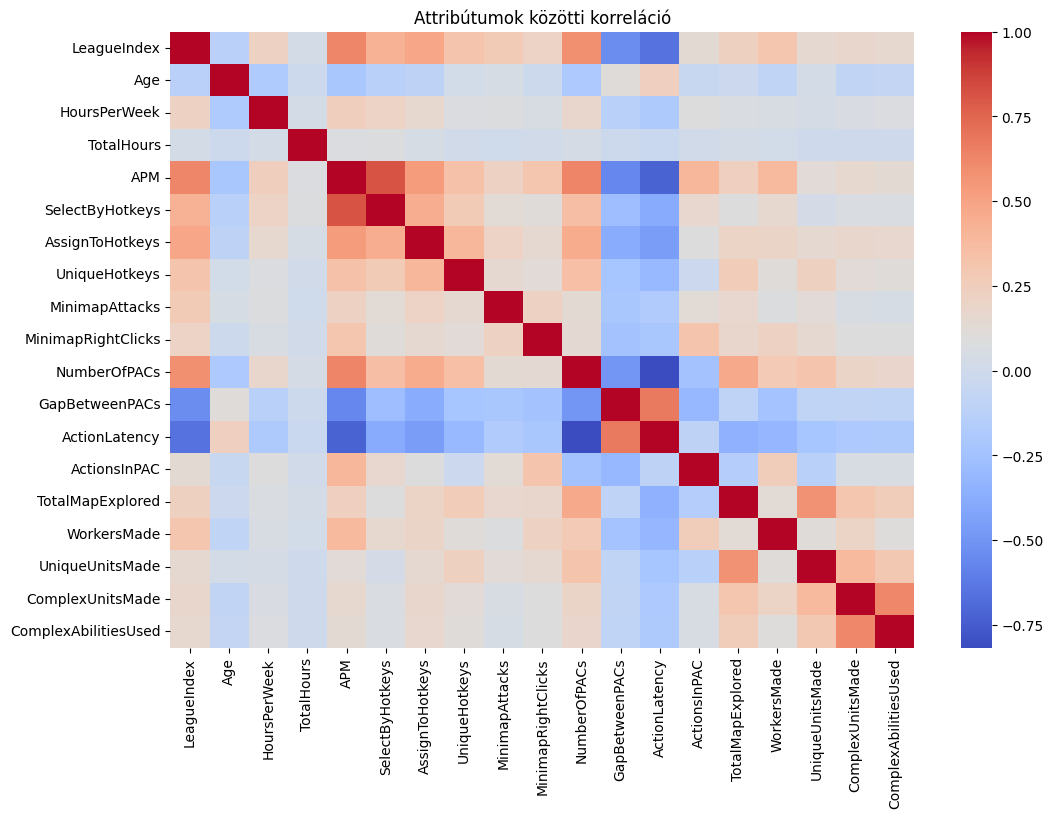

In [5]:
# Korrelációs hőtérkép
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Attribútumok közötti korreláció")
plt.show()

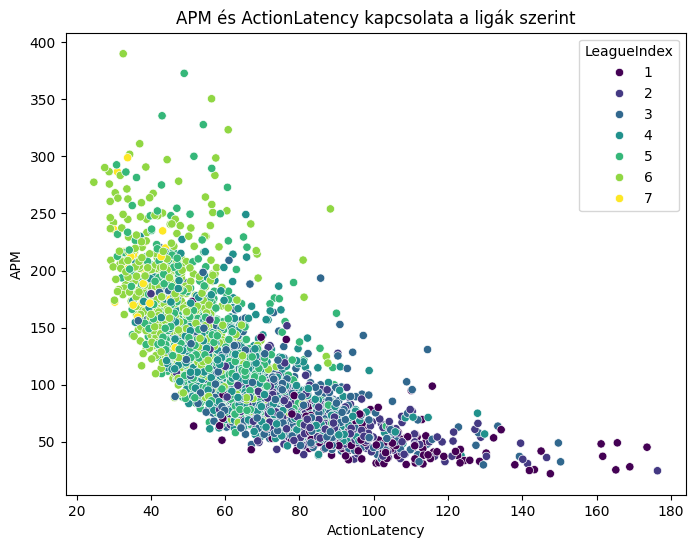

In [6]:
# Scatterplot APM-ActionLatency kapcsolat, LeagueIndex szerint
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ActionLatency', y='APM', hue='LeagueIndex', palette='viridis')
plt.title("APM és ActionLatency kapcsolata a ligák szerint")
plt.show()

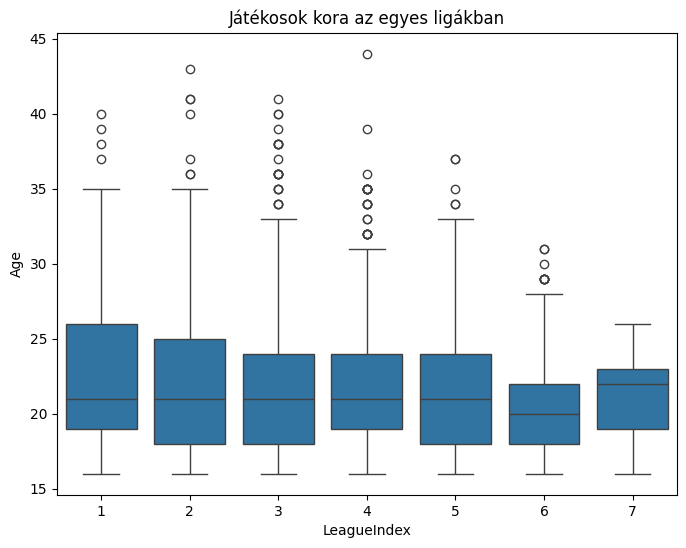

In [7]:
# Boxplot Age eloszlása LeagueIndex-ek között
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='LeagueIndex', y='Age')
plt.title("Játékosok kora az egyes ligákban")
plt.show()

C:\Users\Treon\AppData\Local\Temp\ipykernel_5924\3111997164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['TotalHours'] < 3000], x='LeagueIndex', y='TotalHours', palette='muted')


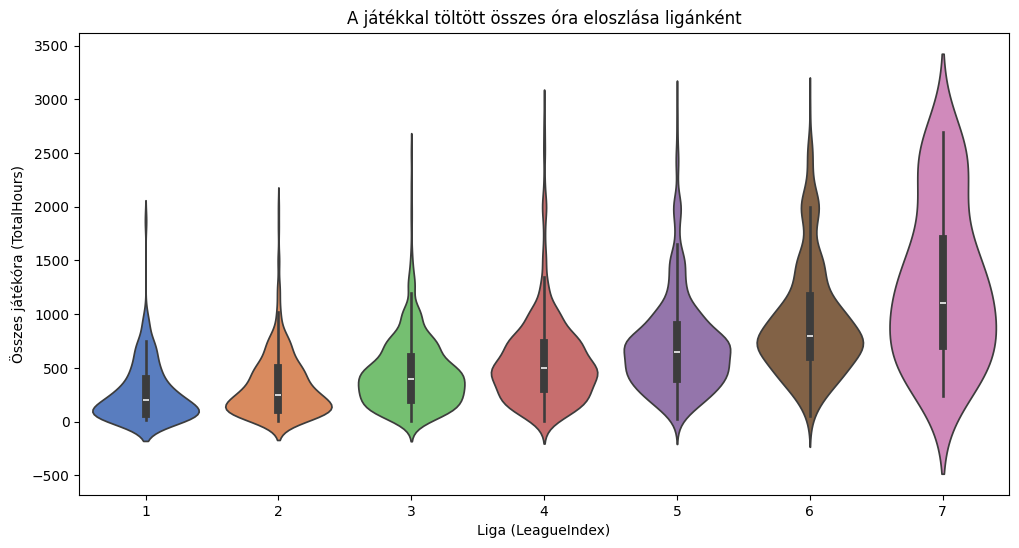

In [14]:
# Histplot TotalHours eloszlás
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[df['TotalHours'] < 3000], x='LeagueIndex', y='TotalHours', palette='muted')
plt.title("A játékkal töltött összes óra eloszlása ligánként")
plt.xlabel("Liga (LeagueIndex)")
plt.ylabel("Összes játékóra (TotalHours)")
plt.show()

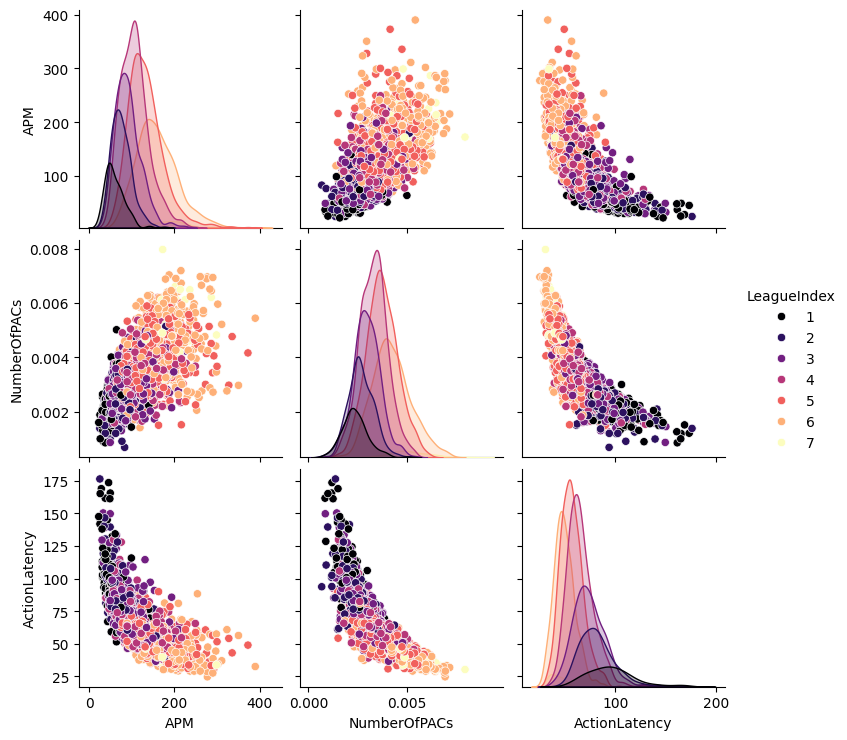

In [10]:
#Pairplot néhány fontosabb
sns.pairplot(df[['APM', 'NumberOfPACs', 'ActionLatency', 'LeagueIndex']], hue='LeagueIndex', palette='magma')
plt.show()

In [ ]:
#Klaszterezés Két különböző algoritmust, a K-Means-t és a DBSCAN-t alkalmazzuk a játékstílusok (APM és PAC adatok) csoportosítására.

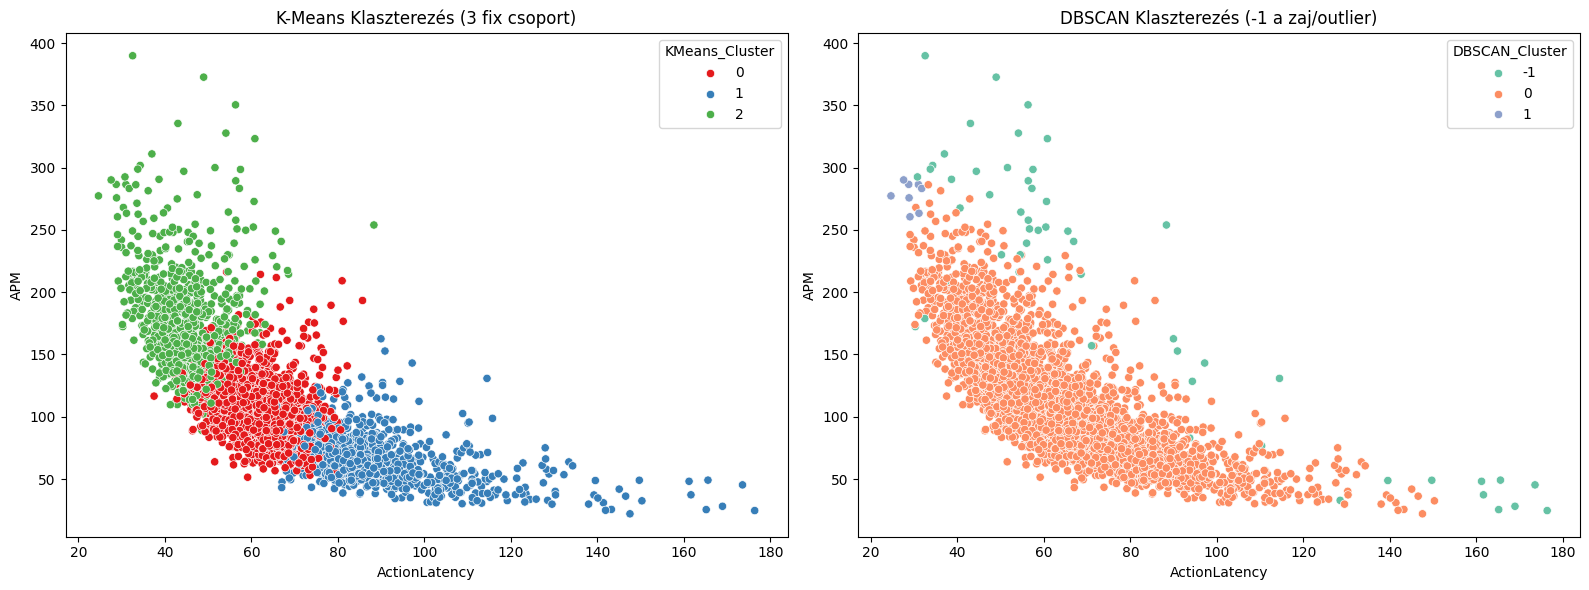

In [18]:
# Klaszterezéshez attribútumok kiválasztása+skálázása
cluster_features = df[['APM', 'ActionLatency', 'NumberOfPACs']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

#K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

#DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

#VIZUALIZÁCIÓ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means ábra
sns.scatterplot(ax=axes[0], data=df, x='ActionLatency', y='APM', hue='KMeans_Cluster', palette='Set1')
axes[0].set_title("K-Means Klaszterezés (3 fix csoport)")

# DBSCAN ábra
sns.scatterplot(ax=axes[1], data=df, x='ActionLatency', y='APM', hue='DBSCAN_Cluster', palette='Set2')
axes[1].set_title("DBSCAN Klaszterezés (-1 a zaj/outlier)")

plt.tight_layout()
plt.show()

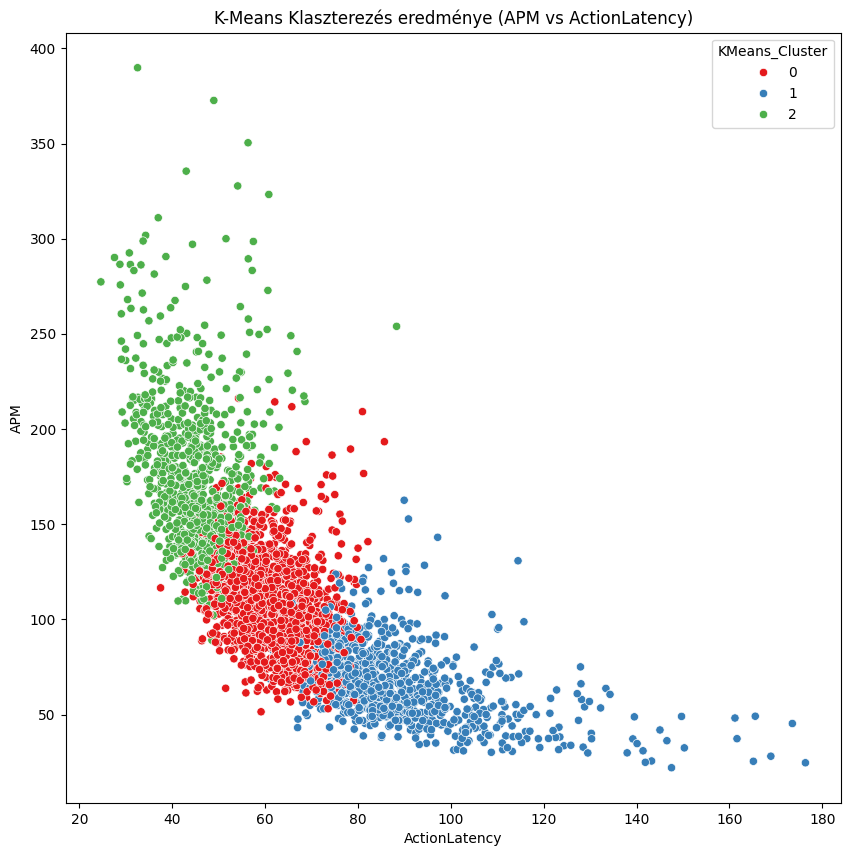

In [12]:
# Eredmény:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='ActionLatency', y='APM', hue='KMeans_Cluster', palette='Set1')
plt.title("K-Means Klaszterezés eredménye (APM vs ActionLatency)")
plt.show()

In [ ]:
#Célváltozó (Y): APM (Action per minute, folytonos).
#Bemeneti változók (X): ActionLatency, NumberOfPACs, Age.

#A korrelációs mátrix alapján ezen változók erős kapcsolatot mutathatnak a játékosok sebességével (APM).
#Célja az APM értékének prediktálása a kor és a reakcióidő alapján.

In [30]:
#Regresszió
X_reg = df[['ActionLatency', 'NumberOfPACs', 'Age']]
y_reg = df['APM']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_lin = lin_reg.predict(X_test_r)

print("Hagyományos Lineáris Regresszió R^2:", r2_score(y_test_r, y_pred_lin))
print("Hagyományos Lineáris Regresszió MSE:", mean_squared_error(y_test_r, y_pred_lin))

Hagyományos Lineáris Regresszió R^2: 0.5373424120891149
Hagyományos Lineáris Regresszió MSE: 1033.4857499883433


Ridge Regresszió R^2: 0.537019161858658
Ridge Regresszió MSE: 1034.207827212595


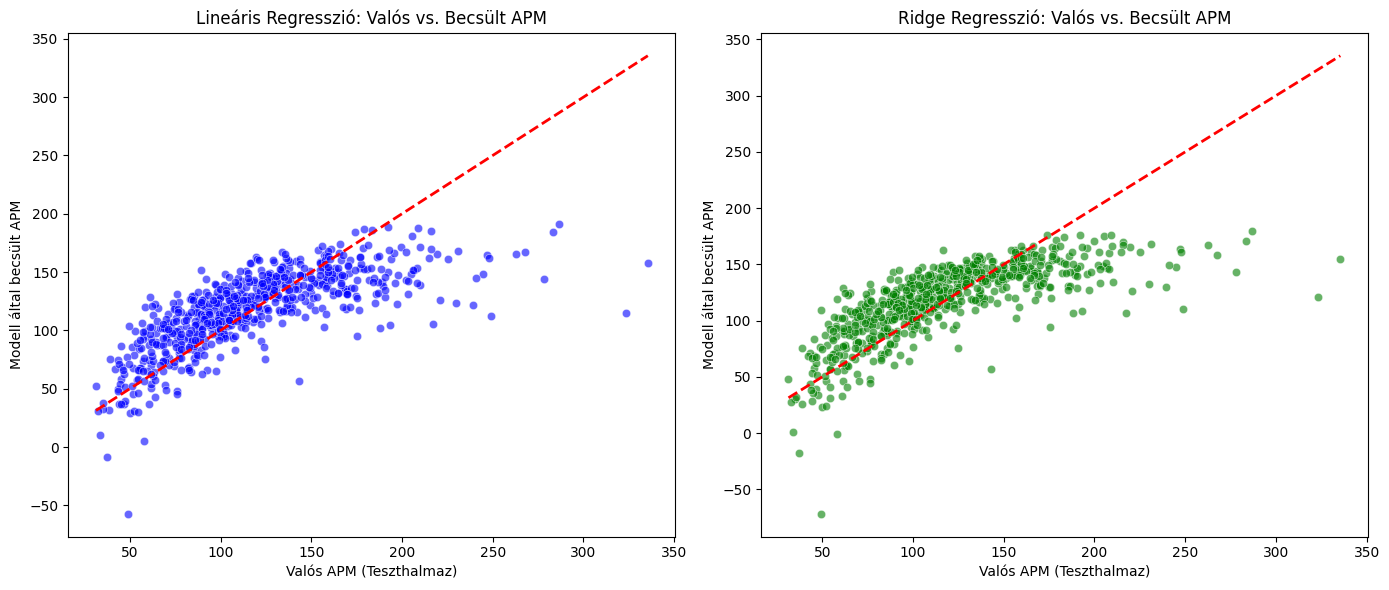

In [31]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_r, y_train_r)
y_pred_ridge = ridge_reg.predict(X_test_r)

print("Ridge Regresszió R^2:", r2_score(y_test_r, y_pred_ridge))
print("Ridge Regresszió MSE:", mean_squared_error(y_test_r, y_pred_ridge))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hagyományos lineáris regresszió ábra
sns.scatterplot(ax=axes[0], x=y_test_r, y=y_pred_lin, alpha=0.6, color='blue')
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2) # 45 fokos vonal
axes[0].set_title("Lineáris Regresszió: Valós vs. Becsült APM")
axes[0].set_xlabel("Valós APM (Teszthalmaz)")
axes[0].set_ylabel("Modell által becsült APM")

# Ridge regresszió ábra
sns.scatterplot(ax=axes[1], x=y_test_r, y=y_pred_ridge, alpha=0.6, color='green')
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1].set_title("Ridge Regresszió: Valós vs. Becsült APM")
axes[1].set_xlabel("Valós APM (Teszthalmaz)")
axes[1].set_ylabel("Modell által becsült APM")

plt.tight_layout()
plt.show()

In [ ]:
#Célváltozó (Y): Létrehozunk egy bináris osztályozási feladatot diszkrét attribútum alapján: IsHighLeague, ami 1, 
#ha a játékos LeagueIndex értéke nagyobb, mint 5 (Diamond és a felett), egyébként 0.
#Bemeneti változók (X): APM, ActionLatency, TotalHours.
#A kérdés, hogy a játékos játékbeli sebessége és tapasztalata (órák száma) alapján megjósolható-e, hogy magasabb ligába tartozik-e.

In [33]:
#Bináris célváltozó
df['IsHighLeague'] = (df['LeagueIndex'] >= 5).astype(int)

X_cls = df[['APM', 'ActionLatency', 'TotalHours']]
y_cls = df['IsHighLeague']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

#Normalizálás a logisztikus regresszióhoz (konvergencia!)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

#Logisztikus reg. (1.)
log_reg_simple = LogisticRegression(penalty=None)
log_reg_simple.fit(X_train_c_scaled, y_train_c)
y_pred_simple = log_reg_simple.predict(X_test_c_scaled)
print("Pontosság:", accuracy_score(y_test_c, y_pred_simple))

#Logisztikus reg. (2.)
log_reg_l2 = LogisticRegression(penalty='l2') 
log_reg_l2.fit(X_train_c_scaled, y_train_c)
y_pred_l2 = log_reg_l2.predict(X_test_c_scaled)
print("L2 (Ridge) modell Pontosság:", accuracy_score(y_test_c, y_pred_l2))


Pontosság: 0.7859281437125748
L2 (Ridge) modell Pontosság: 0.7784431137724551


C:\Users\Treon\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Treon\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
#Az osztályozási feladatot megtartjuk (IsHighLeague prediktálása). 
#Az attribútumok értékeit StandardScaler segítségével normalizáljuk, ami különösen fontos a Support Vector Classifier (SVC) számára.

#A korábban használt 80% - 20% arányú visszatartó (holdout) módszert alkalmazzuk (train_test_split), 
#a választott arány biztosítja, hogy elég adat maradjon a tanításra, de megbízható legyen a tesztelés is.

#Egy Random Forest és egy Support Vector Classifier (SVC) algoritmust tanítunk be az adathalmazon.

#A modelleket Accuracy (pontosság), Classification Report (Precision, Recall, F1-score),
#és a tévesztési mátrix (Confusion Matrix) segítségével értékeljük ki.

Random Forest Eredmények
Accuracy: 0.7724550898203593
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       346
           1       0.77      0.75      0.76       322

    accuracy                           0.77       668
   macro avg       0.77      0.77      0.77       668
weighted avg       0.77      0.77      0.77       668

--- Support Vector Classifier Eredmények ---
Accuracy: 0.7664670658682635
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       346
           1       0.79      0.70      0.74       322

    accuracy                           0.77       668
   macro avg       0.77      0.76      0.76       668
weighted avg       0.77      0.77      0.77       668



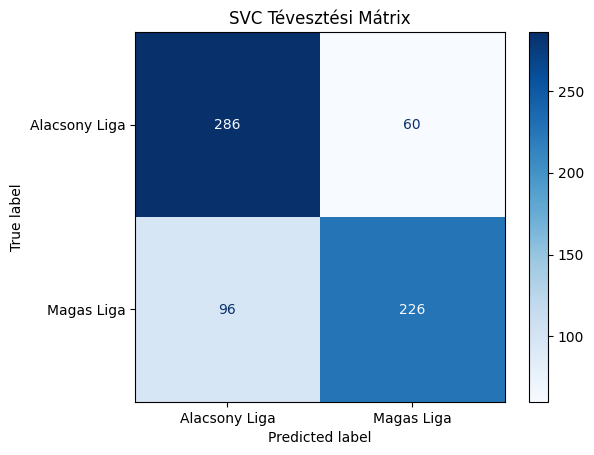

In [24]:
#1. Algoritmus: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c_scaled, y_train_c) 
y_pred_rf = rf_clf.predict(X_test_c_scaled)

print("Random Forest Eredmények")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print(classification_report(y_test_c, y_pred_rf))

#2. Algoritmus: Support Vector Classifier (SVC)
svc_clf = SVC(kernel='rbf', random_state=42)
svc_clf.fit(X_train_c_scaled, y_train_c)
y_pred_svc = svc_clf.predict(X_test_c_scaled)

print("Support Vector Classifier Eredmények")
print("Accuracy:", accuracy_score(y_test_c, y_pred_svc))
print(classification_report(y_test_c, y_pred_svc))

#Kiértékelés: Tévesztési mátrix vizualizálása az SVC modellre
cm = confusion_matrix(y_test_c, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alacsony Liga', 'Magas Liga'])
disp.plot(cmap='Blues')
plt.title("SVC Tévesztési Mátrix")
plt.show()